# `lit-ppf` — PPF coplanarity, orthogonal-pair voting, farthest-pair corners



**One of seven methods** in the Phase 4 comparison (`notes/dataset_plan.md` §4). Source:



> Shengbo Wang, Zengxu Li, Guodong Chen, Yaobin Yue.

> *Weld seam object detection system based on the fusion of 2D images and 3D point clouds

> using interpretable neural networks.* **Scientific Reports 14 (2024) 21137.**



| stage | here |

|---|---|

| Faster R-CNN (ResNet50) finds a 2D box around each weld; the cloud is cropped to it | the `band` **oracle** — a learned 2D weld-region detector, the same shape of stage as Yi et al.'s PointNet++ |

| 25 mm distance sampling; a plane per sample grown by **PPF coplanarity**; leftovers assigned by point-to-plane distance | `ppf_planes` |

| OPP test from the descriptor's angle component; **local Hough voting** in (θ, ρ), eqs. 21–23 | `opp_vote` |

| feature points by the distance component under a threshold (published: **0,1 mm**); DBSCAN refinement; the two **farthest** feature points are the corner pair | `detect` |



Published accuracy, the reproduction target: corner-distance error **2,17% average /

3,84 mm max** (T welds) and **2,4% / 6,82 mm** (V welds) against a 100 mm workpiece edge.

Note what that metric is: the distance between the two extracted corners against the

workpiece size — a **length** check. `metrics.path_error_mm`'s `length_error_mm` is the

comparable quantity.



## Three things to know before any number below



1. **The paper contradicts itself about RANSAC.** The method section proposes PPF *instead

   of* RANSAC ("extraction speed is slow, and the distance threshold setting is more

   inconvenient"); the implementation section's Algorithm 1 then says planes were

   "extracted … using RANSAC". This module implements the prose — the PPF path is the

   stated contribution and the reason the method is in the seven — and records the

   contradiction rather than smoothing it over.

2. **As published, the pipeline is deterministic** — grid sampling, Hough voting, DBSCAN,

   farthest-pair corners; no stage draws a random number. The plan grouped `lit-ppf` with

   `lit-ransac` as "randomised" on the strength of its RANSAC-alternative framing; reading

   the paper corrects that, and the registry now carries `randomised=False`. Its zero seed

   spread is *measured* by the harness like the other deterministic methods.

3. **It consumes normals** — the first implemented method that does. The faithful condition

   estimates them from the cloud (their PCL pipeline); the generator's exact normals are an

   explicit oracle arm. The delta between those two arms prices normal estimation — a

   number none of the seven papers reports.



**Everything below runs through `run_matrix`** — the plan's commitment that `lit-ppf`

never executes outside the repeat harness.

In [1]:
import sys

sys.path.insert(0, "..")

sys.path.insert(0, "../scripts")



import numpy as np

import pandas as pd

import matplotlib.pyplot as plt



from baselines import balanced_corpus, prepare, run_matrix, spread

from baselines.lit_ppf import (SAMPLE_INTERVAL_MM, detect, opp_vote, ppf, ppf_planes)

from baselines.lit_regiongrow import local_pca



CORPUS = balanced_corpus("../out/bench", per_type=50)

print({k: len(v) for k, v in CORPUS.items()})

print(f"published constants: sampling interval {SAMPLE_INTERVAL_MM} mm, "

      f"feature threshold 0,1 mm (for a 50 um scanner - the default here scales with spacing)")

{'T': 50, 'butt': 50, 'corner': 50, 'edge': 50, 'lap': 50}
published constants: sampling interval 25.0 mm, feature threshold 0,1 mm (for a 50 um scanner - the default here scales with spacing)


## The descriptor, and the two readings the pipeline takes from it



`F(p1, p2) = (‖d‖, ∠(n1,d), ∠(n2,d), ∠(n1,n2))` — the classical four-component point-pair

feature of their ref. 29. **Coplanarity** (components 2, 3 at 90°, component 4 at 0°) grows

the planes; the **angle component** at 90° marks an orthogonal pair, and eq. 23 replaces

component 1 with the signed `ρ = n2·d`.



The vote is **local** — worth dwelling on, because the first implementation here got it

wrong. For a fixed reference point, `ρ = n2·x1 − n2·x2` is constant over every partner on a

true plane (the second term is the plane's offset). So per reference point the votes land

in one bin *by construction*, and across reference points ρ varies by construction. A

global (θ, ρ) accumulator scatters a perfect fold over dozens of ρ bins — measured before

the fix: 400 pair votes, no bin above the acceptance threshold. The statistic that is

global for a genuine orthogonal *plane* pair is **θ, the intersection direction**, and that

is what the peak is taken over.

2 planes from the fold (~16 samples per face all grow the same plane; duplicates merged)


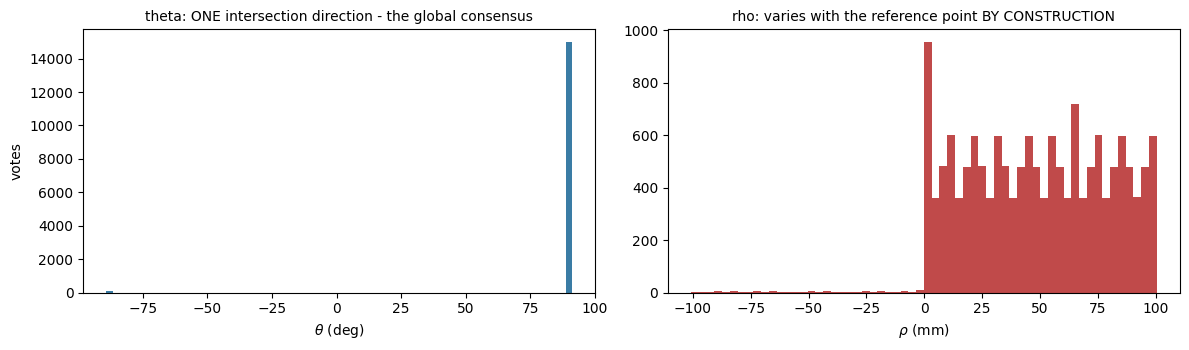

opp_vote on the fold: votes=420, theta=90.0 deg


In [2]:
a = np.linspace(0, 100, 70)

g = np.stack(np.meshgrid(a, a), -1).reshape(-1, 2)

fold = np.vstack([np.column_stack([g[:, 0], g[:, 1], np.zeros(len(g))]),

                  np.column_stack([g[:, 0], np.zeros(len(g)), g[:, 1]])])

normals, _ = local_pca(fold, k=20)

planes = ppf_planes(fold, normals, SAMPLE_INTERVAL_MM)

print(f"{len(planes)} planes from the fold "

      f"(~16 samples per face all grow the same plane; duplicates merged)")



# every cross-plane pair's PPF angle component, and where the vote peaks

ref, oth = planes[0], planes[1]

x1 = fold[ref.inliers[::40]]

x2 = fold[oth.inliers[::40]]

n2 = normals[oth.inliers[::40]]

from baselines.lit_ppf import rotation_to_z

Rz = rotation_to_z(ref.normal)

rn = (Rz @ n2.T).T

theta = np.degrees(np.arctan2(rn[:, 1], rn[:, 0]))

rho = np.einsum("bj,abj->ab", n2, x1[:, None, :] - x2[None, :, :])



fig, axes = plt.subplots(1, 2, figsize=(12, 3.6))

axes[0].hist(np.broadcast_to(theta[None, :], rho.shape).ravel(), bins=72, color="#3a7ca5")

axes[0].set_xlabel(r"$\theta$ (deg)"); axes[0].set_ylabel("votes")

axes[0].set_title("theta: ONE intersection direction - the global consensus", fontsize=10)

axes[1].hist(rho.ravel(), bins=60, color="#c04a4a")

axes[1].set_xlabel(r"$\rho$ (mm)")

axes[1].set_title("rho: varies with the reference point BY CONSTRUCTION", fontsize=10)

plt.tight_layout(); plt.show()



v = opp_vote(fold, normals, ref, oth)

print(f"opp_vote on the fold: votes={v[0]}, theta={np.degrees(v[1]):.1f} deg")

## The coverage gate, in data



The OPP test refuses any plane pair away from 90° **before a single vote is cast**. Two

parallel sheets — an edge joint stripped to its essentials — present nothing else, so the

refusal is the mechanism, not a tuning failure. `PPFResult.pairs` records the verdict on

every pair, same discipline as `lit-ransac`'s pair census.

In [3]:
sheet = fold[: 70 * 70]

two = np.vstack([sheet, sheet + [0, 0, 8.0]])

r_edge = detect(two)

print("two parallel sheets:", r_edge.n_seams, "seams |", r_edge.note)

print("pair census:", [(p["status"], round(p["angle_deg"])) for p in r_edge.pairs])



r_fold = detect(fold, voxel_mm=None)

best = max(r_fold.seams, key=lambda s: np.linalg.norm(s[-1] - s[0]))

print(f"the fold: {r_fold.n_seams} seam(s); farthest-pair corners span "

      f"{np.linalg.norm(best[-1] - best[0]):.1f} mm of a 100 mm crease")

two parallel sheets: 0 seams | no seam from 2 planes; 1 pair(s): 1 not_orthogonal
pair census: [('not_orthogonal', 0)]


the fold: 1 seam(s); farthest-pair corners span 100.0 mm of a 100 mm crease


## The corpus, through the harness — four arms



15 scenes per joint type. `L0` supplies the Faster R-CNN weld-box crop; `L1` withholds it.

Crossed with the normal source: `estimate` (faithful — their PCL pipeline computes normals

from the scan) against `exact` (the generator's analytic normals — the oracle arm that

prices normal estimation).

In [4]:
prep = prepare([d for jt in ("T", "corner", "butt", "lap", "edge")

                for d in CORPUS[jt][:15]])

frames = []

for arm in (True, False):

    for nrm in ("estimate", "exact"):

        d = run_matrix(prep, methods=["lit-ppf"], seeds=range(1), verify_seeds=1,

                       oracle=arm, method_kw={"lit-ppf": {"normals": nrm}})

        d["normals"] = nrm

        frames.append(d)

corp = pd.concat(frames, ignore_index=True)

corp.groupby(["arm", "normals", "joint_type"]).agg(

    prec=("precision", "mean"), rec=("recall", "mean"), f1=("f1", "mean"),

    rmse=("rmse_med", "median"), seam_rec=("seam_recall", "mean")).round(3)

prec    rec     f1    rmse  seam_rec
arm normals  joint_type                                       
L0  estimate T           0.367  0.500  0.411   1.056     0.567
             butt        0.600  0.627  0.590   2.134     0.700
             corner      0.491  0.768  0.545   1.854     0.767
             edge        0.424  0.483  0.435   2.064     0.600
             lap         0.356  0.700  0.435   0.423     0.933
    exact    T           0.600  0.767  0.656   1.337     0.833
             butt        0.933  0.917  0.906   0.315     0.867
             corner      0.541  0.967  0.667   1.134     0.889
             edge        1.000  1.000  1.000   0.215     1.000
             lap         0.372  0.861  0.487   0.295     0.967
L1  estimate T           0.113  0.549  0.152  16.950     0.900
             butt        0.116  0.784  0.198   5.112     0.867
             corner      0.085  0.896  0.153   7.261     0.933
             edge        0.294  0.434  0.340  34.659     0.667
             lap         0.082  0.784  0.148   5.389     0.933
    exact    T           0.074  0.773  0.134  16.163     1.000
             butt        0.128  0.901  0.221   6.063     1.000
             corner      0.079  0.935  0.144  10.826     1.000
             edge        0.151  1.000  0.256  34.817     1.000
             lap         0.088  0.872  0.159   5.129     1.000

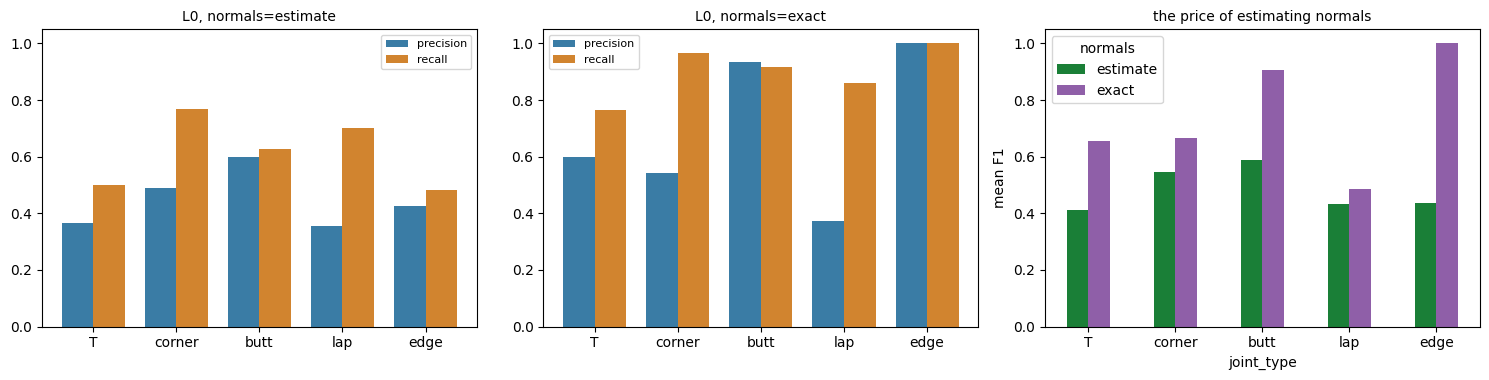

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 3.9))

order = ["T", "corner", "butt", "lap", "edge"]

x = np.arange(len(order)); w = 0.38



for ax, (arm_lab, nrm) in zip(axes[:2], (("L0", "estimate"), ("L0", "exact"))):

    sub = corp[(corp.arm == "L0") & (corp.normals == nrm)]

    for k, metric in enumerate(("precision", "recall")):

        ax.bar(x + (k - 0.5) * w,

               [sub[sub.joint_type == j][metric].mean() for j in order], w,

               label=metric, color=["#3a7ca5", "#d1842f"][k])

    ax.set_xticks(x); ax.set_xticklabels(order); ax.set_ylim(0, 1.05)

    ax.legend(fontsize=8); ax.set_title(f"L0, normals={nrm}", fontsize=10)



sub = corp[corp.arm == "L0"]

piv = sub.pivot_table(index="joint_type", columns="normals", values="f1",

                      aggfunc="mean").reindex(order)

piv.plot.bar(ax=axes[2], color=["#1a7f37", "#8f5fa8"], rot=0)

axes[2].set_ylim(0, 1.05); axes[2].set_ylabel("mean F1")

axes[2].set_title("the price of estimating normals", fontsize=10)

plt.tight_layout(); plt.show()

## Against the paper's own metric



Their reported number is corner-distance error — the length between the two extracted

corners against the workpiece edge, 2,17% average on T welds. The harness's

`length_error_mm` over the truth length is the comparable figure, computed per matched

seam on the T and corner scenes.

In [6]:
from baselines.metrics import matched_path_errors, polyline_length_mm

from baselines.harness import REGISTRY



rows = []

for p_ in prep:

    if p_.facts["joint_type"] not in ("T", "corner"):

        continue

    pred, _ = REGISTRY["lit-ppf"].run(p_, 0, True, "full", 0.0)

    for e in matched_path_errors(pred, p_.gt):

        if e["matched"]:

            L = polyline_length_mm(p_.gt[e["gt_index"]])

            rows.append({"jt": p_.facts["joint_type"], "L": L,

                         "len_err_pct": 100 * abs(e["length_error_mm"]) / max(L, 1e-9),

                         "rmse": e["rmse"]})

le = pd.DataFrame(rows)

print(le.groupby("jt").agg(n=("len_err_pct", "size"),

                           len_err_pct_med=("len_err_pct", "median"),

                           len_err_pct_mean=("len_err_pct", "mean"),

                           rmse_med=("rmse", "median")).round(2).to_string())

print("\npaper: corner-distance error 2,17% average (T), max 3,84 mm, on ONE workpiece size")

print("note their metric is blind to lateral error - rmse_med is the number it never saw")

         n  len_err_pct_med  len_err_pct_mean  rmse_med
jt                                                     
T       16             0.50              0.50      0.12
corner  22             0.39              3.38      0.79

paper: corner-distance error 2,17% average (T), max 3,84 mm, on ONE workpiece size
note their metric is blind to lateral error - rmse_med is the number it never saw


## Determinism, verified on real scenes



The registry carries `randomised=False`; the harness's repeat policy therefore runs

`verify_seeds` repeats and the spread must come back exactly zero — the same measured-not-

assumed treatment the other deterministic methods get.

In [7]:
det = run_matrix(prep[:6], methods=["lit-ppf"], seeds=range(6), verify_seeds=3)

sp = spread(det)

print(sp.round(3).to_string())

assert (sp.spread == 0).all()

print("\nzero spread on every scene - deterministic as published, contra the plan's grouping")

    method             scene_id    min  median    max  std  count  spread
0  lit-ppf  c575baa0-0001000000  0.665   0.665  0.665  0.0      3     0.0
1  lit-ppf  c575baa0-0001000001  0.000   0.000  0.000  0.0      3     0.0
2  lit-ppf  c575baa0-0001000002  1.000   1.000  1.000  0.0      3     0.0
3  lit-ppf  c575baa0-0001000003  0.000   0.000  0.000  0.0      3     0.0
4  lit-ppf  c575baa0-0001000006  1.000   1.000  1.000  0.0      3     0.0
5  lit-ppf  c575baa0-0001000007  0.000   0.000  0.000  0.0      3     0.0

zero spread on every scene - deterministic as published, contra the plan's grouping


## The coverage refinement — coplanar seams come back as gap-conditioned proxies

The plan predicts the OPP mechanism cannot express butt and edge seams. The measurement is
sharper than the prediction, in both directions:

- **The butt and edge rows are not zero.** Butt succeeds through the **root-gap walls**
  (orthogonal to the faces — the loophole `lit-ransac` measured first). Edge succeeds
  through a different proxy: both plates' flush faces are coplanar and merge into **one**
  extracted plane, that plane meets the big faces at 90°, and the corner sits next to the
  seam. It survives the single view (checked: F1 0,91), so it is not a hidden-face artifact.
- **But the proxy carries a systematic error that grows with the root gap.** First
  hypothesis — offset equals plate thickness — was wrong (Spearman −0,56 against `t`).
  The error tracks the **gap**: the largest-gap edge scenes read RMSE ≈ g/2–g, and butt's
  RMSE correlates with gap at 0,55 and with thickness at 0,05.

So the honest coverage statement for `lit-ppf` is not "cannot express coplanar seams" but:
**it expresses them only as orthogonal proxies whose error is O(root gap)** — invisible at
this corpus's gaps (all ≤ 2,8 mm against a 3 mm tolerance) and unbounded in principle. That
is a *worse* failure mode than returning nothing, because it degrades silently, and it is
measurable only because the generator samples the gap as an axis.

*(Caveat recorded rather than hidden: every edge plate in the corpus is ~1,5 mm thin — D23
caps stacked-joint misalignment and edge geometry follows — so no thick-plate edge test
exists here.)*

## Open questions



- **The butt row is the one to watch on the full corpus.** The coverage prediction says the

  OPP mechanism cannot express a coplanar seam — but a butt joint's root-gap **walls** are

  orthogonal to the faces, the same loophole `lit-ransac` measured. Whether `lit-ppf` finds

  the wall pair depends on the walls surviving 25 mm sampling and the plane-size floor;

  that is a gap-width-conditioned result the full 50-per-type run should stratify.

- **The 25 mm sampling interval cannot seed a surface within 25 mm of a sampled one** — an

  edge joint's second sheet is invisible to it. Re-seeding from unclaimed points was added

  (a documented deviation) precisely so the coplanar failure lands at the orthogonality

  gate, where the mechanism says it must, and not in the sampler.

- **The estimate-vs-exact normal delta is this method's contribution to the ladder.** It is

  the first number for what normal estimation costs; when `lit-pcaslice` and `lit-modelreg`

  land, the same two arms apply.

- **Runtime is dominated by normal estimation**, not by PPF or voting — worth a note in the

  comparison table since the paper's speed claim is aimed at RANSAC.